# Ablations and results: Indian Hinglish turn detection

This notebook analyzes completed protocol-v2 experiments registered in the [formal experiment plan](../docs/02_experiment_plan.md). It is paired with the [ablation insights report](../docs/03_ablation_insights.md).

**Question:** which data and model decisions improve complete-vs-incomplete detection on filler- and pause-heavy Hindi/Hinglish proxies, and what safety or latency cost do they create?

**Evidence boundary:** nine audio experiments and one multimodal experiment were already trained and evaluated by repository scripts. This notebook validates and replays immutable artifacts; it does not retrain or overwrite checkpoints. Qualitative cases come from a deterministic 35-example Hindi filler/pause audit scored by four finalist checkpoints.

## Reproducibility setup

All tables are computed from JSON/CSV run artifacts. Protocol, seed, evaluation split, sample count, config/checkpoint presence, and comparator IDs are checked before interpretation.

In [1]:
from pathlib import Path
import json
import sys
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import soundfile as sf
from IPython.display import Audio, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise RuntimeError("Run from repository root or notebooks/ directory")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RUN_ROOT = PROJECT_ROOT / "experiments" / "protocol_v2_seed42"
M1_ROOT = PROJECT_ROOT / "experiments" / "M1_audio_plus_text"
EXPECTED_AUDIO_IDS = [
    "E1_no_augmentation",
    "E2_augmented",
    "E3_mean_pool",
    "E4_last_pool",
    "E5_short_pauses",
    "E6_long_pauses",
    "E7_frozen_encoder",
    "E8_partial_finetune",
    "E11_no_silence",
]
plt.style.use("seaborn-v0_8-whitegrid")
pl.Config.set_tbl_rows(20)
print(f"project={PROJECT_ROOT.name}; run={RUN_ROOT.relative_to(PROJECT_ROOT)}")

project=hinglish-turn-detection; run=experiments\protocol_v2_seed42


## 1. What was run

Training used one-factor comparisons under a common seed, three-epoch budget, split, optimizer, and checkpoint rule. Exact commands:

```powershell
uv run python scripts/run_experiments.py --only E1_no_augmentation E2_augmented E3_mean_pool E4_last_pool E5_short_pauses E6_long_pauses E7_frozen_encoder E8_partial_finetune E11_no_silence --epochs 3 --run-tag protocol_v2_seed42
uv run python scripts/run_experiments.py --only E1_no_augmentation E2_augmented E3_mean_pool E4_last_pool E5_short_pauses E6_long_pauses E7_frozen_encoder E8_partial_finetune E11_no_silence --epochs 3 --run-tag protocol_v2_seed42 --reuse-existing --final-test
uv run python scripts/run_multimodal_experiment.py --reuse-existing --baseline-result experiments/protocol_v2_seed42/E1_no_augmentation/result.json
```

Held-out test was evaluated after validation selection. Because it has now been used, further tuning must return to validation or use a new challenge set.

In [2]:
def load_json(path):
    return json.loads(path.read_text(encoding="utf-8"))


audio_results = [load_json(RUN_ROOT / experiment_id / "result.json") for experiment_id in EXPECTED_AUDIO_IDS]
m1_result = load_json(M1_ROOT / "result.json")
results = audio_results + [m1_result]
by_id = {result["experiment_id"]: result for result in results}

integrity_rows = []
for result in results:
    experiment_id = result["experiment_id"]
    result_root = M1_ROOT if experiment_id == "M1_audio_plus_text" else RUN_ROOT / experiment_id
    metrics = result.get("evaluation_metrics") or result.get("test_metrics")
    integrity_rows.append(
        {
            "experiment": experiment_id,
            "status": result["status"],
            "protocol": result.get("experiment_protocol_version", 2),
            "seed": result.get("seed", 42),
            "split": result.get("evaluation_split", "test"),
            "test_rows": metrics["n_examples"],
            "config": (result_root / "config.yaml").is_file(),
            "checkpoint": Path(result["checkpoint_path"]).is_file(),
        }
    )

integrity = pl.DataFrame(integrity_rows)
display(integrity)
assert integrity["status"].eq("completed").all()
assert integrity["test_rows"].eq(4890).all()
assert integrity["config"].all() and integrity["checkpoint"].all()

experiment,status,protocol,seed,split,test_rows,config,checkpoint
str,str,i64,i64,str,i64,bool,bool
"""E1_no_augmentation""","""completed""",2,42,"""test""",4890,true,true
"""E2_augmented""","""completed""",2,42,"""test""",4890,true,true
"""E3_mean_pool""","""completed""",2,42,"""test""",4890,true,true
"""E4_last_pool""","""completed""",2,42,"""test""",4890,true,true
"""E5_short_pauses""","""completed""",2,42,"""test""",4890,true,true
"""E6_long_pauses""","""completed""",2,42,"""test""",4890,true,true
"""E7_frozen_encoder""","""completed""",2,42,"""test""",4890,true,true
"""E8_partial_finetune""","""completed""",2,42,"""test""",4890,true,true
"""E11_no_silence""","""completed""",2,42,"""test""",4890,true,true


## 2. Overall results

FCR is `P(predict complete | truly incomplete)` and is lower-is-better. It measures premature interruption directly. F1 alone is insufficient: raising completion recall can improve F1 while worsening FCR.

In [3]:
def result_metrics(result):
    return result.get("evaluation_metrics") or result["test_metrics"]


metric_rows = []
for result in results:
    metrics = result_metrics(result)
    cpu = result.get("latency_cpu") or {}
    gpu = result.get("latency_gpu") or {}
    metric_rows.append(
        {
            "experiment": result["experiment_id"],
            "accuracy_pct": 100 * metrics["accuracy"],
            "precision_pct": 100 * metrics["precision"],
            "recall_pct": 100 * metrics["recall"],
            "f1_pct": 100 * metrics["f1"],
            "auc_pct": 100 * metrics["auc"],
            "fcr_pct": 100 * metrics["false_complete_rate"],
            "fp32_mib": result["model_size_mb_fp32"],
            "cpu_ms": cpu.get("latency_ms_mean"),
            "gpu_ms": gpu.get("latency_ms_mean"),
        }
    )

overall = pl.DataFrame(metric_rows).with_columns(pl.exclude("experiment").round(2))
display(overall)

experiment,accuracy_pct,precision_pct,recall_pct,f1_pct,auc_pct,fcr_pct,fp32_mib,cpu_ms,gpu_ms
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""E1_no_augmentation""",87.61,86.62,89.15,87.87,93.64,13.96,30.52,32.49,6.7
"""E2_augmented""",87.75,85.95,90.45,88.14,93.79,14.99,30.52,29.07,6.27
"""E3_mean_pool""",86.05,83.76,89.68,86.62,92.98,17.62,30.14,28.1,5.24
"""E4_last_pool""",87.32,85.58,89.96,87.72,93.86,15.36,30.14,28.38,5.27
"""E5_short_pauses""",87.65,86.09,90.0,88.0,93.58,14.74,30.52,28.79,5.62
"""E6_long_pauses""",87.26,84.86,90.9,87.78,93.35,16.43,30.52,29.63,5.68
"""E7_frozen_encoder""",71.53,69.1,78.59,73.54,77.51,35.61,30.52,29.87,6.25
"""E8_partial_finetune""",87.46,85.08,91.06,87.97,93.32,16.18,30.52,32.07,6.97
"""E11_no_silence""",87.12,86.14,88.66,87.38,93.53,14.45,30.52,25.12,4.91


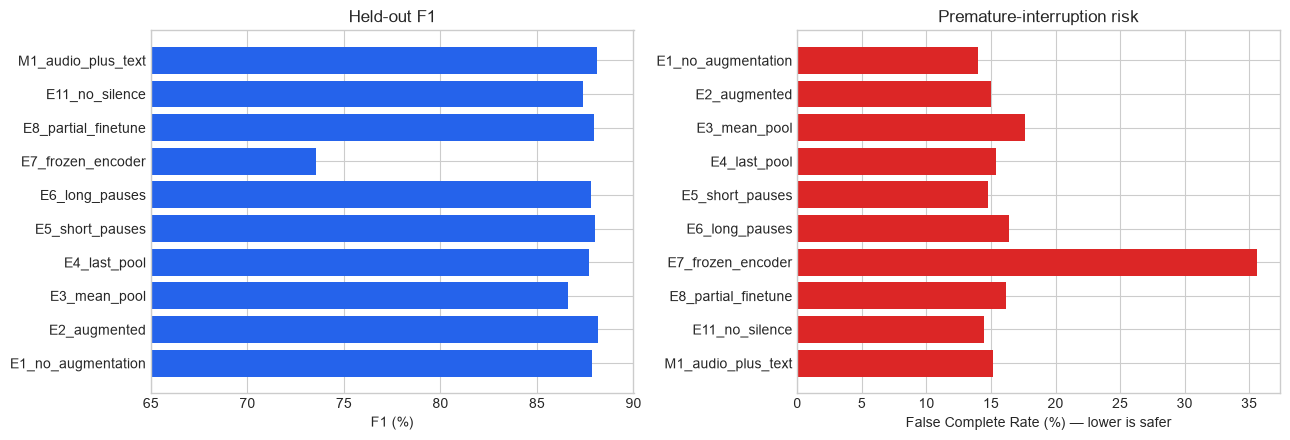

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
names = overall["experiment"].to_list()
axes[0].barh(names, overall["f1_pct"], color="#2563eb")
axes[0].set(xlabel="F1 (%)", title="Held-out F1")
axes[0].set_xlim(65, 90)
axes[1].barh(names, overall["fcr_pct"], color="#dc2626")
axes[1].set(xlabel="False Complete Rate (%) (lower is safer)", title="Premature-interruption risk")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

**Reading:** E2 has best overall F1 (88.14%), but E1 has lowest FCR (13.96%). E7 is not a small degradation; fully frozen Whisper collapses to 73.54% F1 and 35.61% FCR. This establishes that some task-specific encoder adaptation matters more than small augmentation or pooling differences.

## 3. Paired effects against registered comparators

Positive F1 delta is good; negative FCR delta is good. Only registered pairs support causal interpretation. Small sub-one-point differences remain directional because this run has one seed.

experiment,comparator,delta_f1_pp,delta_recall_pp,delta_fcr_pp,delta_auc_pp
str,str,f64,f64,f64,f64
"""E2_augmented""","""E1_no_augmentation""",0.28,1.3,1.03,0.15
"""E3_mean_pool""","""E2_augmented""",-1.52,-0.77,2.63,-0.81
"""E4_last_pool""","""E2_augmented""",-0.42,-0.49,0.37,0.07
"""E5_short_pauses""","""E2_augmented""",-0.14,-0.45,-0.25,-0.21
"""E6_long_pauses""","""E2_augmented""",-0.36,0.45,1.44,-0.44
"""E7_frozen_encoder""","""E2_augmented""",-14.6,-11.87,20.63,-16.28
"""E8_partial_finetune""","""E2_augmented""",-0.17,0.61,1.19,-0.47
"""E11_no_silence""","""E2_augmented""",-0.76,-1.79,-0.54,-0.26
"""M1_audio_plus_text""","""E1_no_augmentation""",0.25,1.42,1.24,0.3


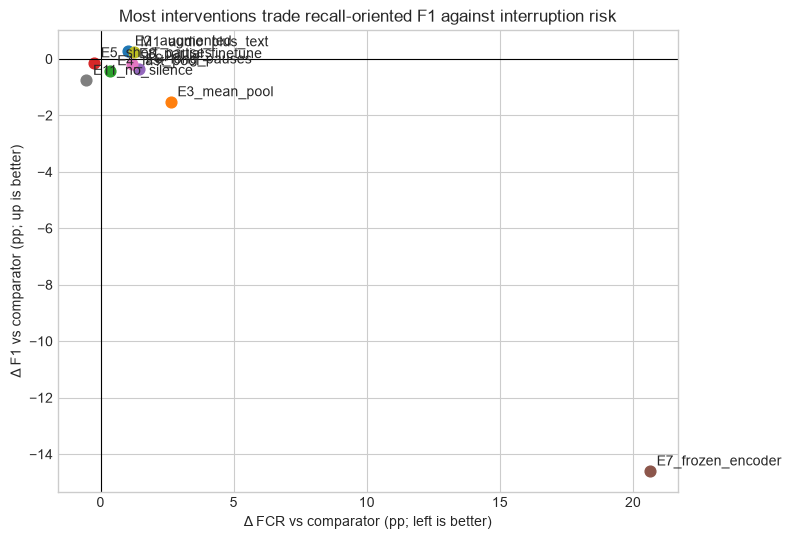

In [5]:
delta_rows = []
for result in results:
    comparator_id = result.get("comparator_id")
    if not comparator_id or comparator_id not in by_id:
        continue
    current = result_metrics(result)
    comparator = result_metrics(by_id[comparator_id])
    delta_rows.append(
        {
            "experiment": result["experiment_id"],
            "comparator": comparator_id,
            "delta_f1_pp": 100 * (current["f1"] - comparator["f1"]),
            "delta_recall_pp": 100 * (current["recall"] - comparator["recall"]),
            "delta_fcr_pp": 100 * (current["false_complete_rate"] - comparator["false_complete_rate"]),
            "delta_auc_pp": 100 * (current["auc"] - comparator["auc"]),
        }
    )

deltas = pl.DataFrame(delta_rows).with_columns(pl.exclude("experiment", "comparator").round(2))
display(deltas)

plt.figure(figsize=(8, 6))
for row in deltas.iter_rows(named=True):
    plt.scatter(row["delta_fcr_pp"], row["delta_f1_pp"], s=60)
    plt.annotate(row["experiment"], (row["delta_fcr_pp"], row["delta_f1_pp"]), xytext=(5, 4), textcoords="offset points")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Δ FCR vs comparator (pp; left is better)")
plt.ylabel("Δ F1 vs comparator (pp; up is better)")
plt.title("Most interventions trade recall-oriented F1 against interruption risk")
plt.show()

## 4. Training dynamics and selection risk

Validation histories confirm each run completed the same three-epoch budget. They also expose why held-out rank must not be treated as stable: E11 achieved strongest validation F1 but did not lead on test.

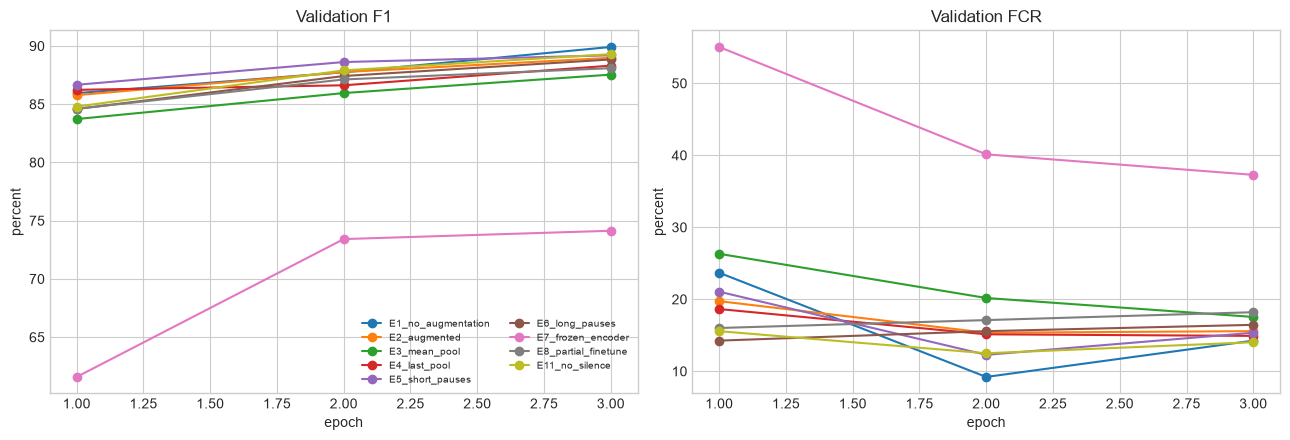

In [6]:
history_rows = []
for experiment_id in EXPECTED_AUDIO_IDS:
    for record in load_json(RUN_ROOT / experiment_id / "history.json"):
        history_rows.append({"experiment": experiment_id, **record})
history = pl.DataFrame(history_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for experiment_id in EXPECTED_AUDIO_IDS:
    part = history.filter(pl.col("experiment") == experiment_id)
    axes[0].plot(part["epoch"], 100 * part["val_f1"], marker="o", label=experiment_id)
    axes[1].plot(part["epoch"], 100 * part["val_false_complete_rate"], marker="o", label=experiment_id)
axes[0].set(title="Validation F1", xlabel="epoch", ylabel="percent")
axes[1].set(title="Validation FCR", xlabel="epoch", ylabel="percent")
axes[0].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 5. Filler- and pause-focused error analysis

Slices come from the same evaluator for every checkpoint. Hindi is only a Hinglish proxy; filler flags are metadata; internal pause is a reproducible low-energy proxy, not a linguistic annotation. Slice notation below keeps support visible.

In [7]:
slice_names = ["hindi", "midfiller", "internal_pause", "hindi_filler_pause", "hard_hinglish_proxy"]
slice_rows = []
for result in results:
    slices = result["error_analysis"]["slices"]
    row = {"experiment": result["experiment_id"]}
    for slice_name in slice_names:
        metrics = slices[slice_name]
        row[f"{slice_name}_n"] = metrics["n"]
        row[f"{slice_name}_f1"] = 100 * metrics["f1"]
        row[f"{slice_name}_fcr"] = 100 * metrics["false_complete_rate"]
    slice_rows.append(row)

slice_results = pl.DataFrame(slice_rows)
compact_slices = slice_results.select(
    "experiment",
    pl.col("hindi_f1").round(2),
    pl.col("hindi_fcr").round(2),
    pl.col("midfiller_f1").round(2),
    pl.col("midfiller_fcr").round(2),
    pl.col("internal_pause_f1").round(2),
    pl.col("internal_pause_fcr").round(2),
    pl.col("hindi_filler_pause_f1").round(2),
    pl.col("hindi_filler_pause_fcr").round(2),
    pl.col("hard_hinglish_proxy_f1").round(2),
    pl.col("hard_hinglish_proxy_fcr").round(2),
)
display(
    pl.DataFrame(
        {
            "slice": slice_names,
            "n": [slice_results[f"{name}_n"][0] for name in slice_names],
        }
    )
)
display(compact_slices)

slice,n
str,i64
"""hindi""",254
"""midfiller""",1830
"""internal_pause""",3124
"""hindi_filler_pause""",159
"""hard_hinglish_proxy""",182


experiment,hindi_f1,hindi_fcr,midfiller_f1,midfiller_fcr,internal_pause_f1,internal_pause_fcr,hindi_filler_pause_f1,hindi_filler_pause_fcr,hard_hinglish_proxy_f1,hard_hinglish_proxy_fcr
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""E1_no_augmentation""",89.21,11.5,84.73,16.79,87.78,12.39,84.72,9.52,82.99,10.28
"""E2_augmented""",90.34,15.93,84.19,17.76,88.55,12.83,87.01,14.29,84.81,14.95
"""E3_mean_pool""",88.97,17.7,83.31,17.76,86.91,15.44,85.16,16.67,83.54,15.89
"""E4_last_pool""",91.72,14.16,84.94,17.33,87.62,13.66,89.74,13.1,88.05,13.08
"""E5_short_pauses""",89.66,16.81,84.26,17.01,87.84,12.83,86.27,14.29,84.08,14.95
"""E6_long_pauses""",90.78,16.81,85.13,18.19,88.28,14.74,87.18,15.48,85.0,15.89
"""E7_frozen_encoder""",73.13,25.66,65.29,36.71,73.64,32.78,66.67,25.0,64.43,24.3
"""E8_partial_finetune""",91.67,13.27,84.67,18.41,88.18,14.49,88.89,11.9,87.18,12.15
"""E11_no_silence""",87.72,16.81,83.93,16.15,87.82,13.02,81.88,15.48,79.74,15.89


### Slice interpretation

- E1 remains safest on Hindi filler+pause and hard-Hinglish FCR.
- E2 improves internal-pause and hard-proxy F1 but worsens hard-proxy FCR: augmentation shifts operating point toward "complete."
- E4 gives strongest Hindi and hard-proxy F1, contradicting original assumption that last-frame pooling would broadly fail under trailing silence.
- E8 nearly matches E2 overall and improves E2's hard-proxy F1/FCR trade-off, making partial tuning strongest efficiency candidate.
- E7 fails every slice, showing frozen ASR features do not expose enough endpoint information under fixed budget.

## 6. Experiment-by-experiment findings

### Original versus augmented data: E1 vs E2

E2 gains **0.28 pp F1** and **1.30 pp recall**, but worsens overall FCR by **1.03 pp** and hard-proxy FCR by **4.67 pp**. Pre-registered safety hypothesis fails. Augmentation helps recall-oriented robustness, not uniformly better separation.

### Pooling: E2 vs E3 vs E4

Attention beats mean by **1.52 pp F1** and **2.63 pp FCR**, supporting temporal selection over uniform averaging. Last-frame pooling remains close overall and leads hard-proxy F1, suggesting endpoint evidence is concentrated near crop boundary. This result led to the later E4 safety repeat.

### Silence policy: E2 vs E5/E6/E11

Broad and short ranges are close. Long-only pauses worsen FCR. Removing silence costs **5.07 pp hard-proxy F1** versus E2, but E2 improves internal-pause FCR by only **0.19 pp**, below planned threshold. Silence helps difficult-case recall; duration-specific safety remains unresolved.

### Encoder tuning: E2 vs E7/E8

Fully frozen encoder loses **14.60 pp F1**. Freezing first two layers stays within **0.17 pp F1** of full tuning and improves hard-proxy trade-off. Some adaptation is essential; adapting every layer is not.

### Audio versus text: E1 vs M1

M1 adds **0.25 pp overall F1** and improves hard-proxy F1, but worsens FCR and raises warm end-to-end latency from **8.71 ms to 240.15 ms**. The text branch helps diagnosis, but its latency and FCR rule it out for live use.

## 7. Qualitative successes, failures, and disagreements

This audit is not another metric estimate. Selection is deterministic: Hindi rows with known filler flags, balanced by label and internal-pause presence, plus Hindi IDs among stored high-confidence errors. Four finalists were rescored at threshold 0.5. Cases below make model behavior inspectable.

In [8]:
qualitative = load_json(RUN_ROOT / "qualitative_examples.json")
model_ids = qualitative["model_ids"]
examples = qualitative["examples"]

def correct_count(example):
    return sum(example["predictions"][model_id]["correct"] for model_id in model_ids)


success_incomplete = next(e for e in examples if e["true_label"] == 0 and e["internal_pause"] and correct_count(e) == 4)
success_complete = next(e for e in examples if e["true_label"] == 1 and e["internal_pause"] and correct_count(e) == 4)
false_complete = next(e for e in examples if e["true_label"] == 0 and correct_count(e) == 0)
false_incomplete = min(
    (e for e in examples if e["true_label"] == 1 and correct_count(e) == 0),
    key=lambda e: np.mean([e["predictions"][model_id]["prob_complete"] for model_id in model_ids]),
)
disagreement = max(
    (e for e in examples if 0 < correct_count(e) < 4),
    key=lambda e: np.ptp([e["predictions"][model_id]["prob_complete"] for model_id in model_ids]),
)
selected_cases = [
    ("consensus success: incomplete", success_incomplete),
    ("consensus success: complete", success_complete),
    ("consensus false complete", false_complete),
    ("consensus false incomplete", false_incomplete),
    ("model disagreement", disagreement),
]

case_rows = []
for case, example in selected_cases:
    row = {
        "case": case,
        "id": example["id"][:8],
        "truth": "complete" if example["true_label"] else "incomplete",
        "internal_pause": example["internal_pause"],
        "midfiller": example["midfiller"],
        "endfiller": example["endfiller"],
        "duration_s": round(example["duration_s"], 2),
    }
    for model_id in model_ids:
        row[model_id] = round(example["predictions"][model_id]["prob_complete"], 3)
    case_rows.append(row)
display(pl.DataFrame(case_rows))

case,id,truth,internal_pause,midfiller,endfiller,duration_s,E1_no_augmentation,E2_augmented,E4_last_pool,E8_partial_finetune
str,str,str,bool,bool,bool,f64,f64,f64,f64,f64
"""consensus success: incomplete""","""00012542""","""incomplete""",true,true,true,10.08,0.011,0.013,0.011,0.015
"""consensus success: complete""","""003d8a0b""","""complete""",true,true,false,3.8,0.896,0.844,0.91,0.851
"""consensus false complete""","""08888b79""","""incomplete""",false,true,false,5.36,0.868,0.769,0.845,0.703
"""consensus false incomplete""","""174e2874""","""complete""",true,true,false,8.2,0.014,0.024,0.019,0.023
"""model disagreement""","""05f3ceab""","""incomplete""",true,true,true,3.72,0.196,0.763,0.433,0.786


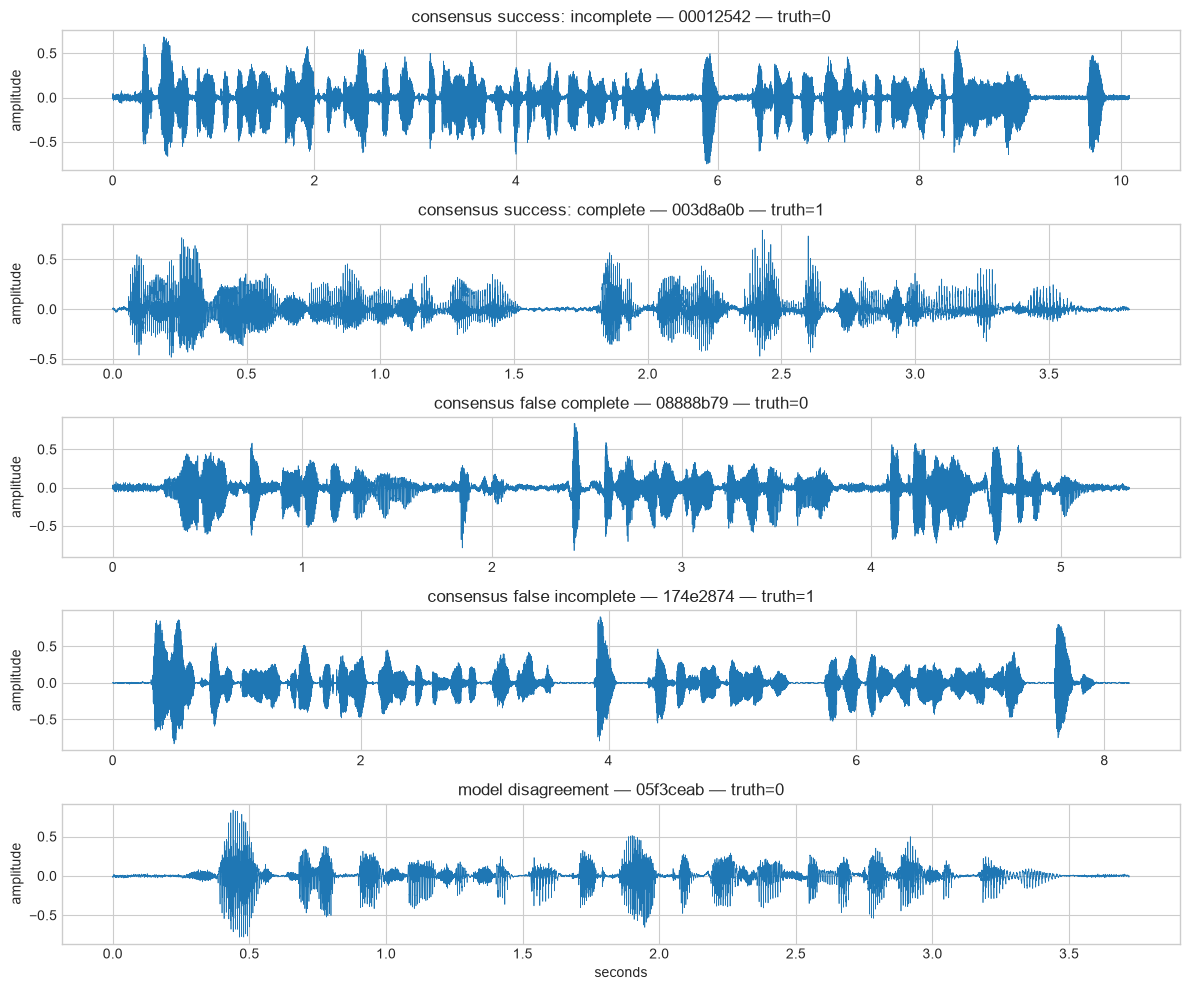

consensus success: incomplete: 00012542


consensus success: complete: 003d8a0b


consensus false complete: 08888b79


consensus false incomplete: 174e2874


model disagreement: 05f3ceab


In [9]:
fig, axes = plt.subplots(len(selected_cases), 1, figsize=(12, 10))
for axis, (case, example) in zip(axes, selected_cases):
    waveform, sample_rate = sf.read(PROJECT_ROOT / example["path"], dtype="float32")
    if waveform.ndim == 2:
        waveform = waveform.mean(axis=1)
    times = np.arange(len(waveform)) / sample_rate
    axis.plot(times, waveform, linewidth=0.5)
    axis.set_title(f"{case}: {example['id'][:8]}, truth={example['true_label']}")
    axis.set_ylabel("amplitude")
axes[-1].set_xlabel("seconds")
plt.tight_layout()
plt.show()

for case, example in selected_cases:
    print(f"{case}: {example['id'][:8]}")
    display(Audio(filename=str(PROJECT_ROOT / example["path"])))

### What listening and probabilities reveal

- All four models correctly recognize both an incomplete and a complete filler-bearing clip. Filler and internal pause alone do not determine the label.
- In the shared false-complete case, every finalist interrupts an incomplete turn. Calibration can help near the threshold, but high-confidence errors need better data or representation.
- The shared false-incomplete case shows the opposite failure: extra delay. Because filler plus pause can sound unfinished even when the publisher label is complete, this example needs manual label review before it is counted purely as model error.
- In the disagreement case, E1 and E4 remain below threshold while E2 and E8 cross it. Augmentation and fine-tuning changed calibration, not only class separation.

Audio has no transcript, code-switch label, or human ambiguity rating. Linguistic explanation beyond metadata and waveform is therefore intentionally limited.

## 8. Most important learning: data versus model

1. Fully freezing the encoder harms F1 by 14.60 pp, a much larger effect than the augmentation or pooling changes.
2. Full augmentation modestly raises F1 but also raises premature-interruption risk. Synthetic variety is not automatically safer data.
3. Pooling matters once the representation is useful. Mean pooling clearly loses; attention is a sound default; last-frame pooling still needs confirmation on hard cases.
4. Partial fine-tuning preserves overall quality and improves hard-proxy balance with fewer trainable parameters.
5. The small text-branch recall and F1 gains do not justify 27.6x live latency and worse FCR.
6. Better evidence matters more than another small head variation. The project still needs speaker-disjoint Hinglish with transcripts, pause and filler annotations, and ambiguity review.

## 9. Decisions driven by evidence

| Candidate | Decision | Reason |
|---|---|---|
| E1 | Safety finalist | Lowest overall and hard-proxy FCR |
| E2 | Keep as high-recall comparator | Best overall F1; safety criterion failed |
| E3 | Drop | Mean pooling dilutes endpoint evidence |
| E4 | Hard-case finalist | Best AUC and hard-proxy F1; repeatability unknown |
| E5 | Do not prefer yet | No decisive gain over broad pauses |
| E6 | Drop long-only policy | Worse FCR without decisive F1 gain |
| E7 | Drop under current budget | Frozen representation fails badly |
| E8 | Efficiency finalist | Near-E2 F1 with stronger hard-case balance |
| E11 | Keep silence augmentation | Removing silence hurts hard-proxy F1 |
| M1 | Offline diagnostic only | FCR and end-to-end latency fail adoption gate |

The follow-up safety study repeated E1, E4, and E8 across three seeds and calibrated thresholds on validation data. Validation summaries selected E4 seed 44 at threshold 0.5777403; its one-time held-out result was 9.84% FCR, 83.26% completion recall, and 86.29% F1. The next decision should come from a human speaker-disjoint Hinglish set, not more tuning against the current test set.

## 10. Limits

- One seed; small differences have no confidence interval.
- Hindi/filler/pause slices are Hinglish proxies, not verified code-switch annotations.
- Low-energy pause detector is not human VAD.
- No speaker IDs; split cannot prove speaker disjointness.
- Test set has been opened once; future decisions need validation or new H1.
- Threshold fixed at 0.5 during ablations.
- Three epochs ensure equal budget, not per-model convergence optimum.

These limits narrow claims; they do not erase controlled evidence.